In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Face Detection with OpenCV

In [3]:
nadia = cv2.imread("/content/drive/MyDrive/Colab Notebooks/ComputerVision/DATA/Nadia_Murad.jpg",0)
dennis = cv2.imread("/content/drive/MyDrive/Colab Notebooks/ComputerVision/DATA/Denis_Mukwege.jpg",0)
solvey = cv2.imread("/content/drive/MyDrive/Colab Notebooks/ComputerVision/DATA/solvay_conference.jpg",0)

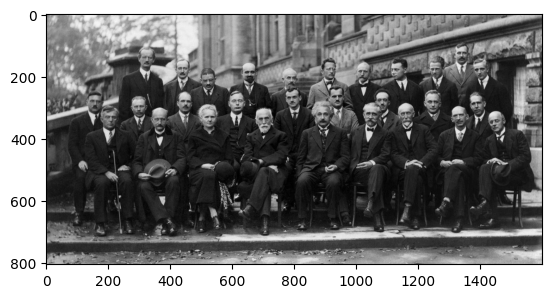

In [4]:
plt.imshow(solvey,cmap="gray")

In [5]:
face_cascade = cv2.CascadeClassifier("/content/drive/MyDrive/Colab Notebooks/ComputerVision/DATA/haarcascades/haarcascade_frontalface_default.xml")

In [6]:
def detect_face(img):
  face_img = img.copy()
  face_rects = face_cascade.detectMultiScale(face_img)
  for (x,y,w,h) in face_rects:
    cv2.rectangle(face_img,(x,y),(x+w,y+h),(255,255,255),10)
  return face_img

In [7]:
dennis_detect = detect_face(dennis)
nadia_detect = detect_face(nadia)
solvey_detect = detect_face(solvey)

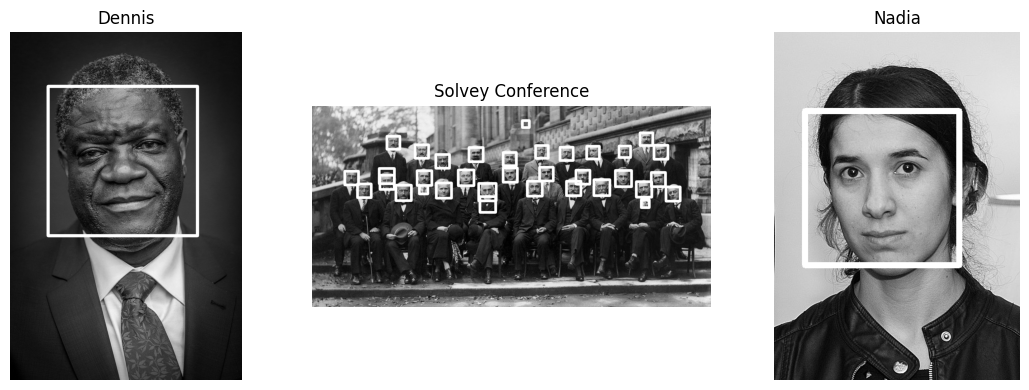

In [8]:
plt.figure(figsize=(12,4))

# 1st image
plt.subplot(1,3,1)
plt.imshow(dennis_detect, cmap="gray")
plt.title("Dennis")
plt.axis("off")

# 2nd image
plt.subplot(1,3,2)
plt.imshow(solvey_detect, cmap="gray")
plt.title("Solvey Conference")
plt.axis("off")

# 3rd image
plt.subplot(1,3,3)
plt.imshow(nadia_detect, cmap="gray")
plt.title("Nadia")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
def adj_face_detect(img):
  face_img = img.copy()
  face_rects = face_cascade.detectMultiScale(face_img,scaleFactor=1.2,minNeighbors=5)
  for (x,y,w,h) in face_rects:
    cv2.rectangle(face_img,(x,y),(x+w,y+h),(255,255,255),10)
  return face_img


In [10]:
solvey_detect_plus = adj_face_detect(solvey)

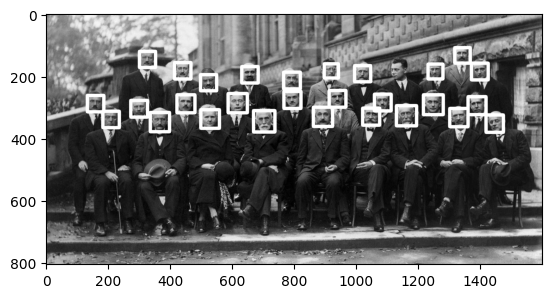

In [11]:
plt.imshow(solvey_detect_plus,cmap="gray")

## Eye Detection

In [12]:
eye_cascade = cv2.CascadeClassifier("/content/drive/MyDrive/Colab Notebooks/ComputerVision/DATA/haarcascades/haarcascade_eye.xml")

In [13]:
def detect_eye(img):
  face_img = img.copy()
  eye_rects = eye_cascade.detectMultiScale(face_img)
  for (x,y,w,h) in eye_rects:
    cv2.rectangle(face_img,(x,y),(x+w,y+h),(255,255,255),10)
  return face_img


In [14]:
nadia_eye = detect_eye(nadia)
dennis_eye = detect_eye(dennis)
solvey_eye = detect_eye(solvey)

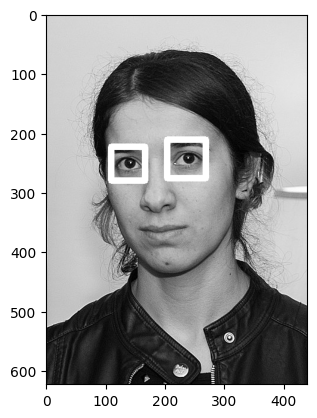

In [15]:
plt.imshow(nadia_eye,cmap="gray")

## Car Plate Detection

In [48]:
car_plate = cv2.imread("/content/drive/MyDrive/Colab Notebooks/ComputerVision/DATA/car_plate.jpg")

In [49]:
def display(img):
  fig = plt.figure(figsize=(10,8))
  ax = fig.add_subplot(111)
  new_img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
  ax.imshow(new_img)

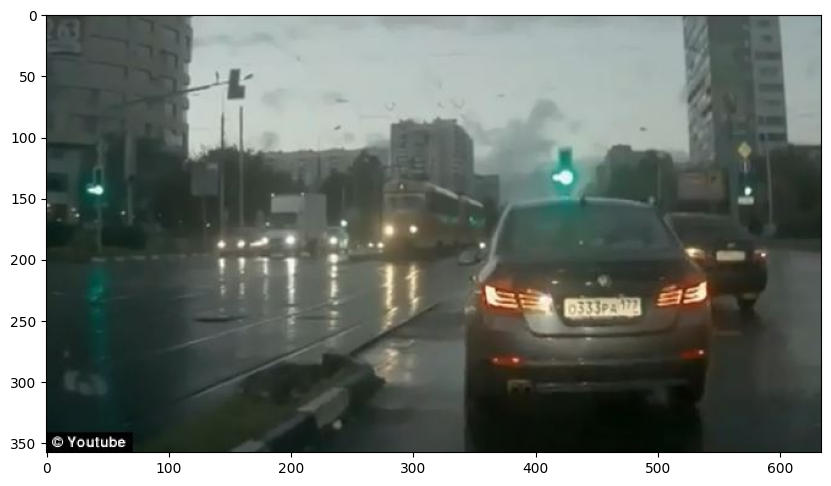

In [50]:
display(car_plate)

In [51]:
plate_cascade = cv2.CascadeClassifier("/content/drive/MyDrive/Colab Notebooks/ComputerVision/DATA/haarcascades/haarcascade_russian_plate_number.xml")

In [58]:
def detect_plate(img):
  plate_img = img.copy()
  plate_rects = plate_cascade.detectMultiScale(plate_img,scaleFactor=1.3,minNeighbors=3)
  for (x,y,w,h) in plate_rects:
    cv2.rectangle(plate_img,(x,y),(x+w,y+h),(0,255,0),4)
  return plate_img

In [59]:
detect_plate_img = detect_plate(car_plate)

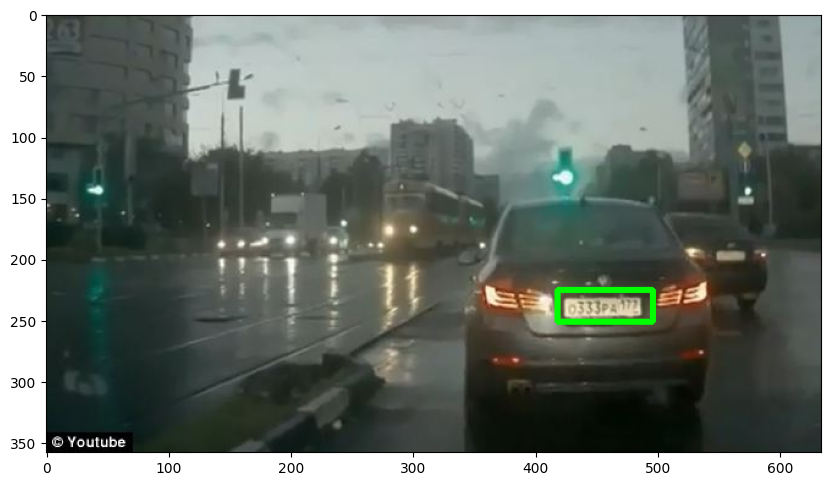

In [60]:
display(detect_plate_img)

In [61]:
def detect_and_blur_plate(img):
  plate_img = car_plate.copy()
  roi = car_plate.copy()
  plate_rects = plate_cascade.detectMultiScale(plate_img,scaleFactor=1.3,minNeighbors=3)
  for (x,y,w,h) in plate_rects:
    roi = roi[y:y+h,x:x+w]
    blurred_roi = cv2.medianBlur(roi,7)
    plate_img[y:y+h,x:x+w] = blurred_roi
  return plate_img

In [62]:
result = detect_and_blur_plate(car_plate)

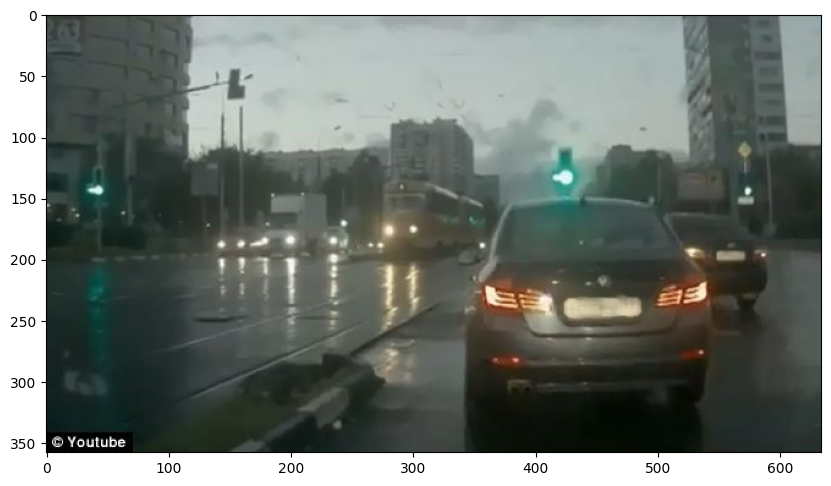

In [63]:
display(result)